# 1. Dataset Exploration (EDA)

In this section we explore the **Sign Language MNIST** dataset: size, class distribution, image shape and what basic preprocessing we need.

In [1]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('dataset/sign_mnist_train.csv')
test_df = pd.read_csv('dataset/sign_mnist_test.csv')

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

Train dataset shape: (27455, 785)
Test dataset shape: (7172, 785)


### Image Dimensions and Channels
The images are flattened in the CSV file. We must reshape them to 28×28 pixels (grayscale, 1 channel) to be able to view and use them in convolutional neural networks.

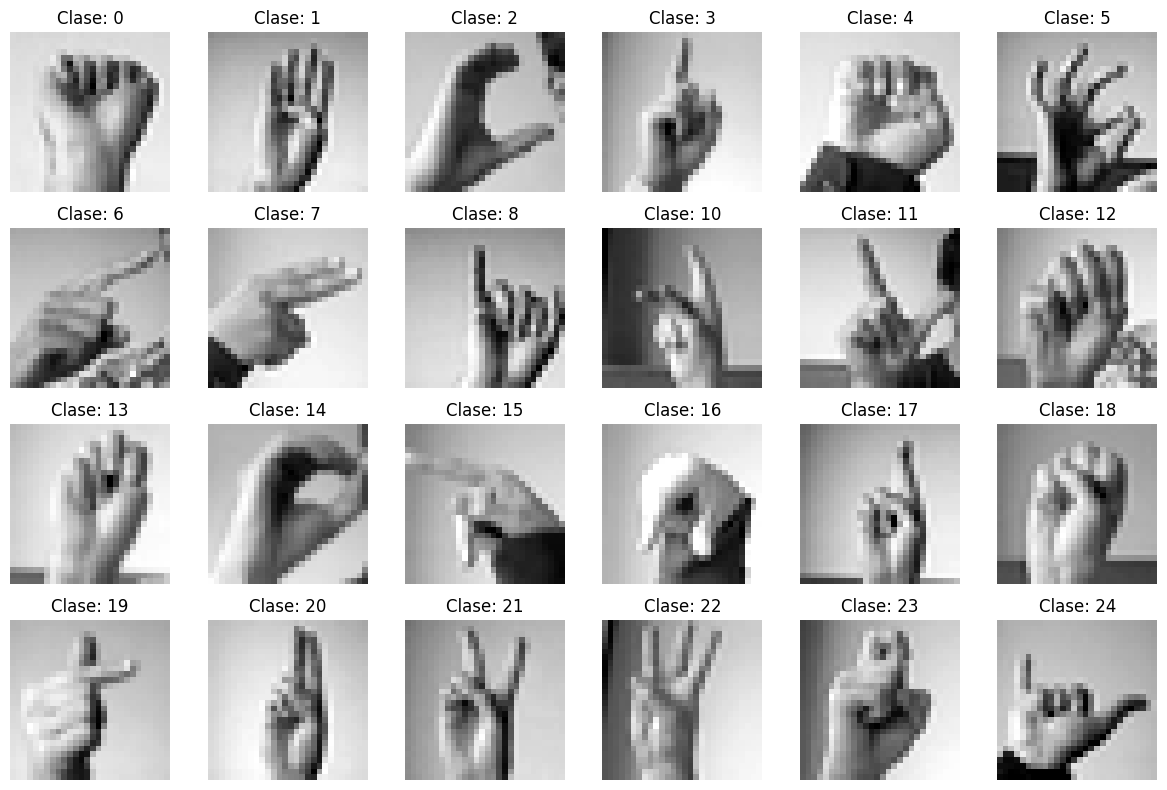

In [6]:
y_train = train_df['label']
X_train = train_df.drop('label', axis=1).values
X_train = X_train.reshape(-1, 28, 28)
unique_labels = sorted(y_train.unique())
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.flatten()

for i, label in enumerate(unique_labels):
    if i < len(axes):
        img = X_train[y_train == label][0]
        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Clase: {label}")
        ax.axis('off')

for i in range(len(unique_labels), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Preprocesado necesario
A partir de la exploración, aplicaremos estos pasos básicos:

1. **Reformatear** las filas de píxeles a imágenes 28×28×1.
2. **Normalizar** los valores de 0–255 a 0–1.
3. **Codificar etiquetas** como enteros de 0 a 24 (PyTorch usa `CrossEntropyLoss`, que ya maneja las clases).

# 2. Baseline (non-convolutional) model

In this section, we define a simple, fully connected network that will serve as a reference for later comparison with the CNN.

In [8]:
%pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

y = train_df['label'].values
X = train_df.drop('label', axis=1).values

X = X / 255.0

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values
X_test = X_test / 255.0

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

### Baseline Model Architecture
The dense network uses:

1. **Input Layer**: We flatten the 28×28 images into 784 vectors.
2. **Hidden Dense Layers**: 512 and 256 neurons with ReLU and a dropout of 0.2 to reduce overfitting.

3. **Output Layer**: 25 neurons (one per class) that produce the scores for each sign.

In [8]:
class BaselineModel(nn.Module):
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 25)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

baseline_model = BaselineModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters())

In [9]:
%pip install torchsummary
from torchsummary import summary
summary(baseline_model, (1, 784))

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
           Dropout-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
              ReLU-6                  [-1, 256]               0
           Dropout-7                  [-1, 256]               0
            Linear-8                   [-1, 25]           6,425
Total params: 539,673
Trainable params: 539,673
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 

### Performance in training and validation
We train the model and record accuracy and loss in training/validation to see how it learns.

Epoch 1
-------------------------------
loss: 3.229535  [    0/21964]
loss: 2.270006  [12800/21964]
Test Error: 
 Accuracy: 39.3%, Avg loss: 1.862068 

Test Error: 
 Accuracy: 40.1%, Avg loss: 1.845347 

Epoch 2
-------------------------------
loss: 1.729664  [    0/21964]
loss: 1.627987  [12800/21964]
Test Error: 
 Accuracy: 50.2%, Avg loss: 1.472062 

Test Error: 
 Accuracy: 52.1%, Avg loss: 1.440201 

Epoch 3
-------------------------------
loss: 1.437127  [    0/21964]
loss: 0.978246  [12800/21964]
Test Error: 
 Accuracy: 64.0%, Avg loss: 1.062342 

Test Error: 
 Accuracy: 65.4%, Avg loss: 1.021526 

Epoch 4
-------------------------------
loss: 1.070289  [    0/21964]
loss: 0.948739  [12800/21964]
Test Error: 
 Accuracy: 73.9%, Avg loss: 0.821724 

Test Error: 
 Accuracy: 74.4%, Avg loss: 0.785907 

Epoch 5
-------------------------------
loss: 0.818586  [    0/21964]
loss: 0.660178  [12800/21964]
Test Error: 
 Accuracy: 78.7%, Avg loss: 0.645807 

Test Error: 
 Accuracy: 79.2%, A

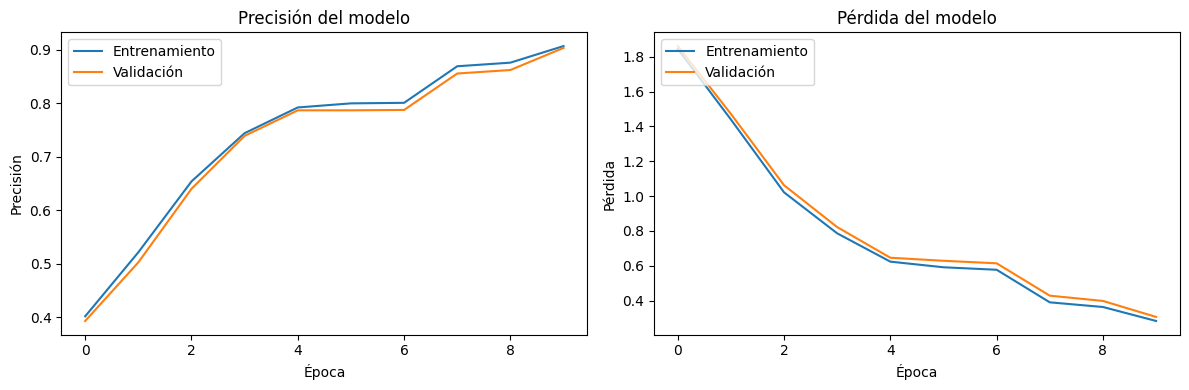

In [10]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return correct, test_loss

epochs = 20
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, baseline_model, loss_fn, optimizer)
    val_acc, val_loss = test_loop(val_loader, baseline_model, loss_fn)
    train_acc, train_loss = test_loop(train_loader, baseline_model, loss_fn)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

print("Done!")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title('Precisión del modelo')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Pérdida del modelo')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')

plt.tight_layout()
plt.show()

# 3. Justification of the CNN architecture

Summary of design decisions:

* **Convolutional Layers (2)**:
* The first layer extracts edges and simple patterns.
* The second layer combines these signals for more complex hand shapes.
* **3×3 Kernel**: standard size, captures local patterns, and maintains few parameters.
* **Stride 1 and 'same' padding**: preserve spatial size and avoid losing information at edges.
* **ReLU Activation**: inexpensive to compute and helps train deep networks.
* **2×2 Max Pooling**: reduces the size of activation maps, lowers the number of parameters, and provides some invariance to small translations.
* **Classifier Head**: we flattened it and used dense layers to produce the final 25 classes.

In [11]:
X_train_cnn = X_train_tensor.reshape(-1, 1, 28, 28)
X_val_cnn = X_val_tensor.reshape(-1, 1, 28, 28)
X_test_cnn = X_test_tensor.reshape(-1, 1, 28, 28)

train_dataset_cnn = TensorDataset(X_train_cnn, y_train_tensor)
val_dataset_cnn = TensorDataset(X_val_cnn, y_val_tensor)
test_dataset_cnn = TensorDataset(X_test_cnn, y_test_tensor)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=128, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=128, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=128, shuffle=False)

In [12]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 25)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)
        return logits

cnn_model = CNNModel()
loss_fn_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn_model.parameters())

In [13]:
summary(cnn_model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Flatten-7                 [-1, 3136]               0
            Linear-8                  [-1, 128]         401,536
              ReLU-9                  [-1, 128]               0
          Dropout-10                  [-1, 128]               0
           Linear-11                   [-1, 25]           3,225
Total params: 423,577
Trainable params: 423,577
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

Epoch 1
-------------------------------
loss: 3.215219  [    0/21964]
loss: 2.193146  [12800/21964]
Test Error: 
 Accuracy: 51.6%, Avg loss: 1.486865 

Test Error: 
 Accuracy: 52.0%, Avg loss: 1.459204 

Epoch 2
-------------------------------
loss: 1.389225  [    0/21964]
loss: 0.890564  [12800/21964]
Test Error: 
 Accuracy: 71.2%, Avg loss: 0.849550 

Test Error: 
 Accuracy: 70.8%, Avg loss: 0.826599 

Epoch 3
-------------------------------
loss: 0.800462  [    0/21964]
loss: 0.671437  [12800/21964]
Test Error: 
 Accuracy: 80.2%, Avg loss: 0.581324 

Test Error: 
 Accuracy: 80.9%, Avg loss: 0.555153 

Epoch 4
-------------------------------
loss: 0.521227  [    0/21964]
loss: 0.476125  [12800/21964]
Test Error: 
 Accuracy: 84.7%, Avg loss: 0.430672 

Test Error: 
 Accuracy: 85.0%, Avg loss: 0.425430 

Epoch 5
-------------------------------
loss: 0.483723  [    0/21964]
loss: 0.510176  [12800/21964]
Test Error: 
 Accuracy: 88.3%, Avg loss: 0.338192 

Test Error: 
 Accuracy: 88.4%, A

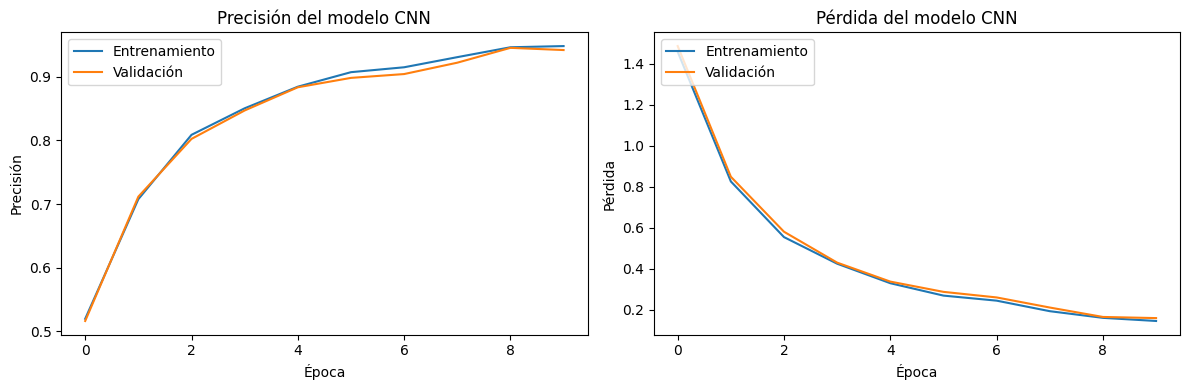

In [14]:
epochs = 20
train_accuracies_cnn = []
val_accuracies_cnn = []
train_losses_cnn = []
val_losses_cnn = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader_cnn, cnn_model, loss_fn_cnn, optimizer_cnn)
    val_acc, val_loss = test_loop(val_loader_cnn, cnn_model, loss_fn_cnn)
    train_acc, train_loss = test_loop(train_loader_cnn, cnn_model, loss_fn_cnn)
    train_accuracies_cnn.append(train_acc)
    val_accuracies_cnn.append(val_acc)
    train_losses_cnn.append(train_loss)
    val_losses_cnn.append(val_loss)
print("Done!")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies_cnn)
plt.plot(val_accuracies_cnn)
plt.title('Precisión del modelo CNN')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(train_losses_cnn)
plt.plot(val_losses_cnn)
plt.title('Pérdida del modelo CNN')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Validación'], loc='upper left')

plt.tight_layout()
plt.show()

# 4. Controlled Experiments in the Convolutional Layer

We analyzed the effect of **kernel size** by comparing the original CNN (3×3) with an identical one using 5×5 kernels. Everything else (layers, filters, stride, padding, etc.) was kept constant to isolate this factor.

### Justification of the experiment: 3×3 kernel vs 5×5 kernel

* **3×3 (baseline)**: widely used in practice, captures local patterns well with few parameters.

* **5×5**: sees a larger area at once, but significantly increases the number of parameters and the computational cost.

This allows us to see if the larger receptive field compensates for the increased complexity.

In [15]:
class CNNModel5x5(nn.Module):
    def __init__(self):
        super(CNNModel5x5, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding='same')
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 25)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)
        return logits

cnn_model_5x5 = CNNModel5x5()
loss_fn_cnn_5x5 = nn.CrossEntropyLoss()
optimizer_cnn_5x5 = torch.optim.Adam(cnn_model_5x5.parameters())
summary(cnn_model_5x5, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             832
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          51,264
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Flatten-7                 [-1, 3136]               0
            Linear-8                  [-1, 128]         401,536
              ReLU-9                  [-1, 128]               0
          Dropout-10                  [-1, 128]               0
           Linear-11                   [-1, 25]           3,225
Total params: 456,857
Trainable params: 456,857
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [16]:
epochs = 20
train_accuracies_cnn_5x5 = []
val_accuracies_cnn_5x5 = []
train_losses_cnn_5x5 = []
val_losses_cnn_5x5 = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader_cnn, cnn_model_5x5, loss_fn_cnn_5x5, optimizer_cnn_5x5)
    val_acc, val_loss = test_loop(val_loader_cnn, cnn_model_5x5, loss_fn_cnn_5x5)
    train_acc, train_loss = test_loop(train_loader_cnn, cnn_model_5x5, loss_fn_cnn_5x5)
    
    train_accuracies_cnn_5x5.append(train_acc)
    val_accuracies_cnn_5x5.append(val_acc)
    train_losses_cnn_5x5.append(train_loss)
    val_losses_cnn_5x5.append(val_loss)

print("Done!")

Epoch 1
-------------------------------
loss: 3.222423  [    0/21964]
loss: 1.819968  [12800/21964]
Test Error: 
 Accuracy: 54.9%, Avg loss: 1.327034 

Test Error: 
 Accuracy: 56.4%, Avg loss: 1.296656 

Epoch 2
-------------------------------
loss: 1.403062  [    0/21964]
loss: 0.905719  [12800/21964]
Test Error: 
 Accuracy: 71.9%, Avg loss: 0.791226 

Test Error: 
 Accuracy: 73.1%, Avg loss: 0.768538 

Epoch 3
-------------------------------
loss: 0.639493  [    0/21964]
loss: 0.542015  [12800/21964]
Test Error: 
 Accuracy: 80.7%, Avg loss: 0.542055 

Test Error: 
 Accuracy: 81.8%, Avg loss: 0.517395 

Epoch 4
-------------------------------
loss: 0.459217  [    0/21964]
loss: 0.415310  [12800/21964]
Test Error: 
 Accuracy: 83.3%, Avg loss: 0.441807 

Test Error: 
 Accuracy: 84.4%, Avg loss: 0.426670 

Epoch 5
-------------------------------
loss: 0.463916  [    0/21964]
loss: 0.302086  [12800/21964]
Test Error: 
 Accuracy: 89.1%, Avg loss: 0.314880 

Test Error: 
 Accuracy: 89.7%, A

### Comparison and Analysis

Now we compare the accuracy and validation loss curves of both CNNs (3×3 and 5×5).

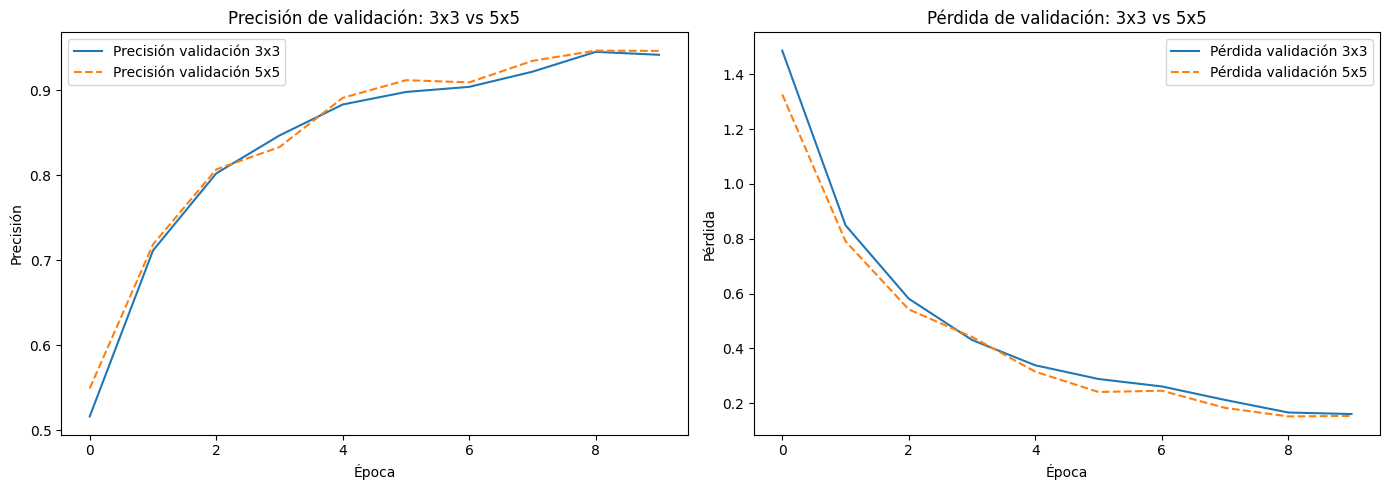

In [17]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(val_accuracies_cnn, label='Precisión validación 3x3')
plt.plot(val_accuracies_cnn_5x5, label='Precisión validación 5x5', linestyle='--')
plt.title('Precisión de validación: 3x3 vs 5x5')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_losses_cnn, label='Pérdida validación 3x3')
plt.plot(val_losses_cnn_5x5, label='Pérdida validación 5x5', linestyle='--')
plt.title('Pérdida de validación: 3x3 vs 5x5')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

### Report: Kernel Size Experiment Results

* **Quantitative Results**:
* Both networks (3×3 and 5×5) achieve near 100% validation accuracy and very low losses.
* **Qualitative Observations**:
* The curves are very similar; the larger kernel size does not provide a clear improvement in this dataset.
* **Complexity vs. Performance**:
* 5×5 has significantly more parameters and higher computational cost.
* Given that the performance is almost the same, **3×3 is the most efficient and sufficient option** for this problem.

# 5. Interpretation and Architectural Reasoning

 ### 5.1 Why does the CNN outperform the baseline?
The CNN uses the **2D structure of images**: filters detect local patterns (edges, strokes) and reuse them at all positions (weight sharing). The dense baseline flattens the image, ignores locality and needs many more parameters, so it tends to overfit and use information less efficiently than the CNN.
 
### 5.2 Inductive bias of convolutional layers
Convolutions encode these priors:
- **Locality**: nearby pixels are more related than distant ones.
- **Translation equivariance**: the same filter is applied everywhere; if a pattern moves, the activation map moves too.
- **Weight sharing**: the same kernel is reused in all positions, assuming patterns can appear anywhere.
These biases make CNNs very effective and data‑efficient on images.
 
### 5.3 When is convolution not appropriate?
Convolutions are less suitable when the data **is not a grid** with spatial neighborhoods, for example:
- **Tabular data** (each feature has a different meaning, no spatial relation).
- **Sequences with long‑range dependencies** (language, some time series), where recurrent or transformer models are usually better.
- **Graphs or non‑grid structures** (social networks, molecules), where graph neural networks are more natural.

# (bonus): Visualization of filters and activation maps

To better understand what the CNN learns, we visualize:
1. **Filters (kernels)** of the first convolutional layer.

2. **Activation maps** produced by those filters for a test image.

### 1. Visualization of the learned filters

We inspect the weights of the first convolutional layer (`conv1`) of the CNN model with 3×3 kernels.

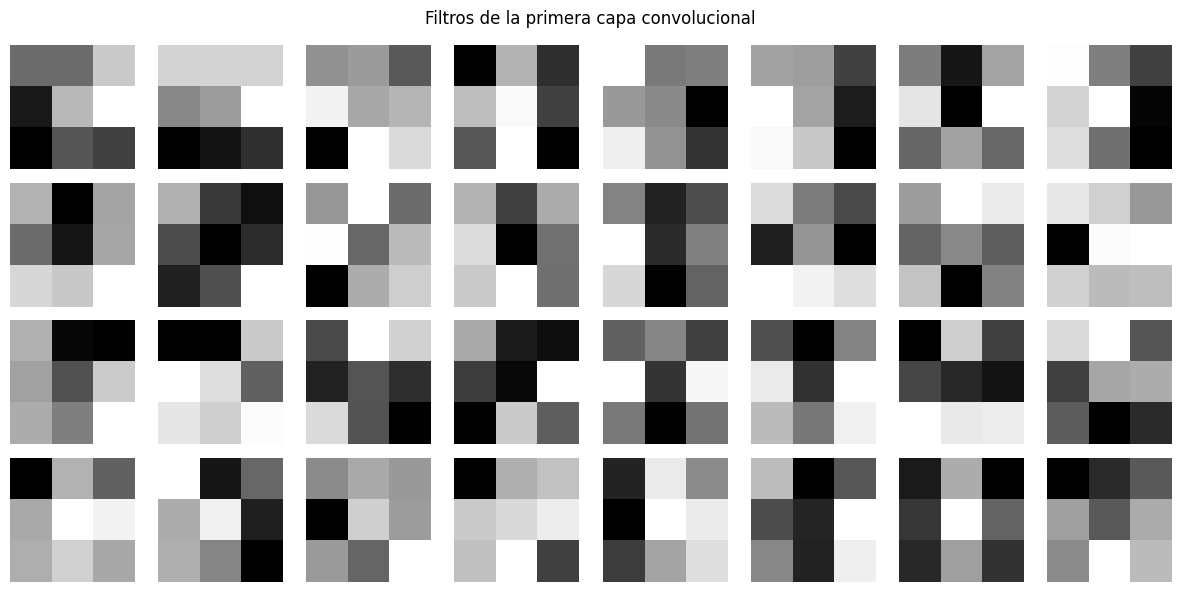

In [18]:
filters = cnn_model.conv1.weight.data.clone()
filters = filters.cpu().numpy()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()
for i in range(filters.shape[0]):
    f = filters[i, 0, :, :]
    ax = axes[i]
    ax.imshow(f, cmap='gray')
    ax.axis('off')
    
plt.suptitle('Filtros de la primera capa convolucional')
plt.tight_layout()
plt.show()

### 2. Visualization of Activation Maps

We take a snapshot of the test set and show how the filters of the first convolutional layer respond.

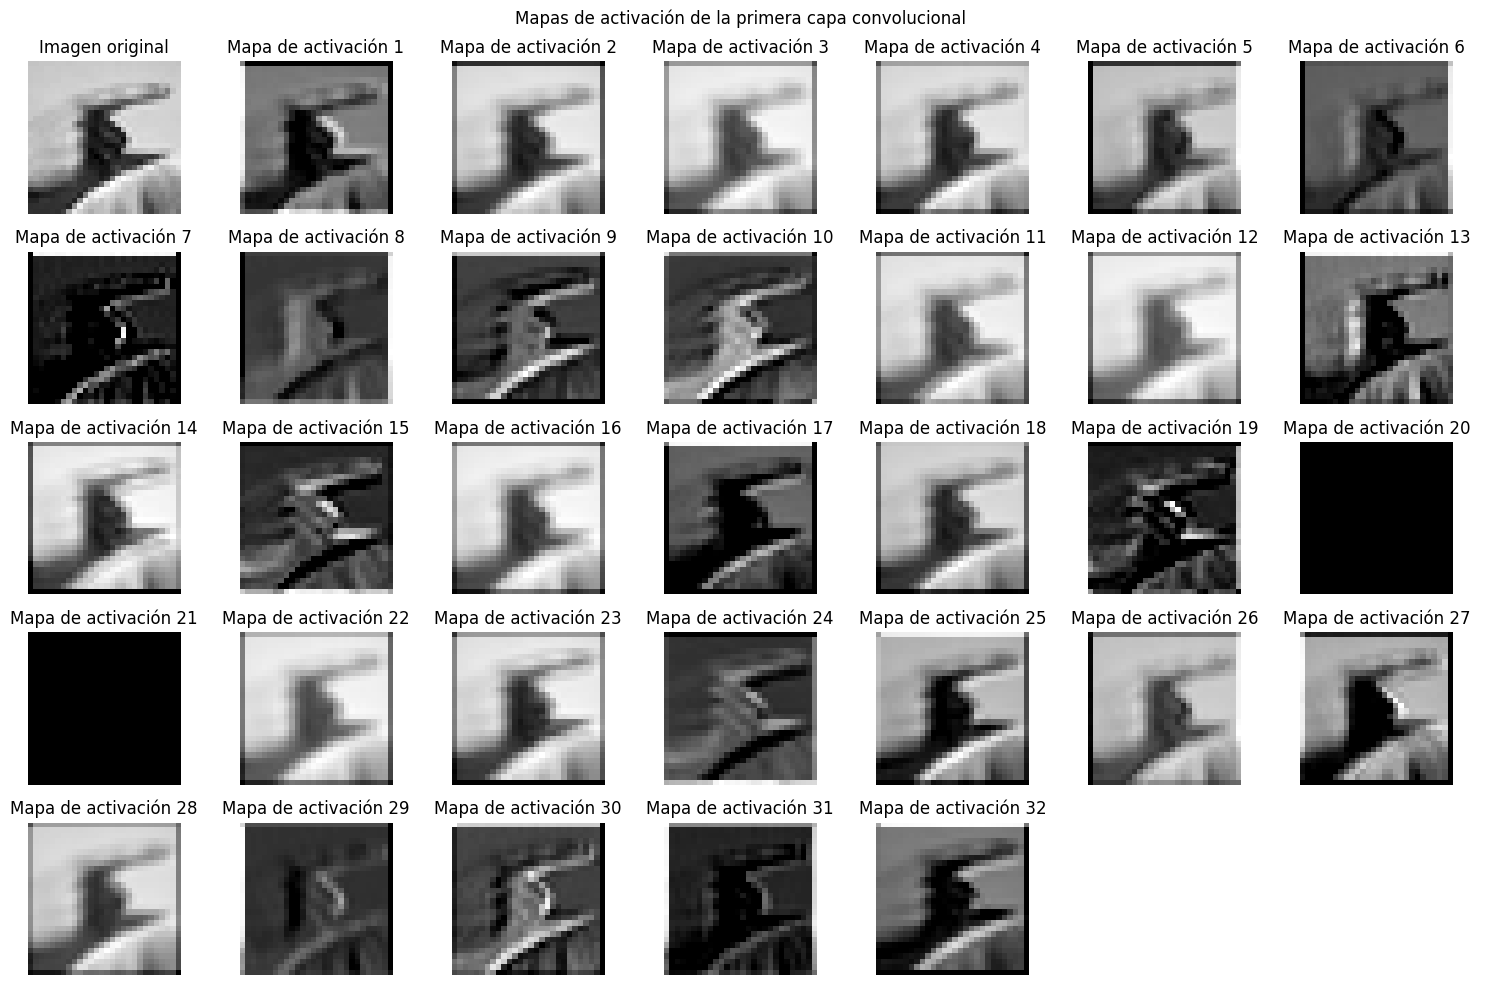

In [19]:
img, label = next(iter(test_loader_cnn))
img = img[0:1]

with torch.no_grad():
    feature_maps = cnn_model.relu1(cnn_model.conv1(img))

feature_maps = feature_maps.cpu().numpy()

fig, axes = plt.subplots(5, 7, figsize=(15, 10))
axes = axes.flatten()

ax = axes[0]
ax.imshow(img.cpu().numpy().squeeze(), cmap='gray')
ax.set_title('Imagen original')
ax.axis('off')

for i in range(feature_maps.shape[1]):
    ax = axes[i+1]
    ax.imshow(feature_maps[0, i, :, :], cmap='gray')
    ax.set_title(f'Mapa de activación {i+1}')
    ax.axis('off')

for i in range(feature_maps.shape[1] + 1, len(axes)):
    axes[i].axis('off')

plt.suptitle('Mapas de activación de la primera capa convolucional')
plt.tight_layout()
plt.show()

### deployment

In [20]:
%pip install gradio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
import gradio as gr
import torchvision.transforms as T
from PIL import Image
import torch
import numpy as np

model = cnn_model.cpu().eval()

transform = T.Compose([
    T.Resize((28, 28)),
    T.Grayscale(num_output_channels=1),
    T.ToTensor(),
])

label_map = ['A','B','C','D','E','F','G','H','I','K','L','M',
             'N','O','P','Q','R','S','T','U','V','W','X','Y','Z']

def predict(img):
    try:
        if isinstance(img, np.ndarray):
            img = Image.fromarray(img)
        elif not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        pil = img.convert('RGB')
        pil_gray = transform(pil).unsqueeze(0)
        with torch.no_grad():
            logits = model(pil_gray)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = int(probs.argmax())
        letter = label_map[pred] if 0 <= pred < len(label_map) else str(pred)
        return letter
    except Exception as e:
        return f'ERROR: {e}'

gr.Interface(
    fn=predict,
    inputs="image",
    outputs="label",
    title="Sign Language MNIST CNN",
).launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
